In [1]:
from __future__ import annotations
import numpy as np, pandas as pd
from pathlib import Path
from typing import Literal, Optional, Tuple, Dict, List
from pandas.api.types import is_numeric_dtype
import warnings; warnings.filterwarnings("ignore")

# Estadística / distancias
from scipy.stats import ks_2samp, mannwhitneyu
from scipy.spatial.distance import cdist

# Evidently (para "evidently_default")
from evidently import Report
from evidently.presets import DataDriftPreset

# === Rutas de entrada (ajusta a tu repo) ===
plant_files = {
    "planta1": Path("../df_procesados/df_planta_1.csv"),
    "planta2": Path("../df_procesados/df_planta_2.csv"),
    "planta3": Path("../df_procesados/df_planta_3.csv"),
}

flag_files = {
    "planta1": Path("../df_procesados/flags_p1.csv"),
    "planta2": Path("../df_procesados/flags_p2.csv"),
    "planta3": Path("../df_procesados/flags_p3.csv"),
}

# Carpeta raíz de salida (1 subcarpeta por planta)
ROOT_OUT = Path("../reportes_DriftFinal")
ROOT_OUT.mkdir(parents=True, exist_ok=True)

# === Parámetros globales ===
PLANTS      = ["planta1","planta2","planta3"]
STRATEGIES  = ["decay","golden","seasonal"]   # ajusta si no usarás seasonal
METRICS     = ["evidently_default","ks","mannwhitney","psi","wasserstein"]
CURRENT_WINDOW = "3D"      # ventana actual para el "test" (resumen)
RESAMPLE        = None   # o la frecuencia que uses
RESAMPLE_AGG    = "mean"  # o 'median'
EXCLUDE_COLUMNS = [  # columnas a excluir del análisis de drift
    'pH Ecualizador 2 (Tk 250m3)', "Conductividad DAF", "Temperatura DAF", 
    'pH entrada a Ecualizador 1', "Flujo Aire Reactor 1", "OD Reactor 1"
]

# Criterios para "drifted"
KS_ALPHA          = 0.05
MWU_ALPHA         = 0.05
PSI_THRESHOLDS    = (0.1, 0.25)   # leve/moderado; >0.25 fuerte
WASS_THRESHOLDS   = (None, None)  # puedes setear por-sensor si quieres

In [2]:
def load_df(path: Path, parse_dates: str = "date_time") -> pd.DataFrame:
    df = pd.read_csv(path)

    if parse_dates not in df.columns:
        raise ValueError(f"{path.name}: no existe la columna temporal '{parse_dates}'")

    # Parse robusto (soporta formatos mixtos); elimina filas que no parsearon
    dt = pd.to_datetime(df[parse_dates], errors="coerce", infer_datetime_format=True)
    bad = dt.isna().sum()
    if bad:
        # Si quieres NO borrar, cámbialo por un warning y fillna
        df = df.loc[~dt.isna()].copy()
        dt = dt.loc[~dt.isna()]

    df = df.drop(columns=[parse_dates])
    df.insert(0, parse_dates, dt.values)

    # Index datetime ordenado, sin duplicados
    df = df.set_index(parse_dates).sort_index()
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()

    # Opcional: si tu data está en America/Santiago y viene naive:
    # df.index = df.index.tz_localize("America/Santiago", nonexistent="shift_forward", ambiguous="NaT")

    # Colapsa duplicados de timestamp si existieran (promedio)
    if df.index.has_duplicates:
        df = df.groupby(level=0).mean(numeric_only=True)

    # Mantén sólo numéricas y sin constantes (igual que antes)
    num = df.select_dtypes(include=[np.number])
    nunique = num.nunique(dropna=True)
    df = num.loc[:, nunique.gt(1)]

    if df.empty:
        raise ValueError(f"{path.name}: tras limpieza, no quedaron columnas numéricas útiles")

    return df


def uniform_numeric(df: pd.DataFrame) -> pd.DataFrame:
    # Deja solo columnas numéricas y elimina constantes
    num = df.select_dtypes(include=[np.number])
    nunique = num.nunique(dropna=True)
    return num.loc[:, nunique.gt(1)]

def resample_df(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    if rule is None: 
        return df
    return df.resample(rule).mean()

def select_window(df: pd.DataFrame, end: pd.Timestamp, win: str) -> pd.DataFrame:
    start = end - pd.Timedelta(win)
    return df.loc[start:end]

def nonempty_intersection(a: pd.DataFrame, b: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # deja sólo columnas comunes y no vacías
    common = a.columns.intersection(b.columns)
    A = a[common].dropna(how="all")
    B = b[common].dropna(how="all")
    return A, B

def psi_score(ref: np.ndarray, cur: np.ndarray, bins: int = 10) -> float:
    # PSI clásico por percentiles de referencia
    if len(ref) == 0 or len(cur) == 0:
        return np.nan
    qs = np.linspace(0, 1, bins+1)
    cuts = np.unique(np.quantile(ref, qs))
    if len(cuts) < 2:
        return np.nan
    ref_hist, _ = np.histogram(ref, bins=cuts)
    cur_hist, _ = np.histogram(cur, bins=cuts)
    ref_pct = np.maximum(ref_hist / ref_hist.sum(), 1e-9)
    cur_pct = np.maximum(cur_hist / cur_hist.sum(), 1e-9)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

def wasserstein_1d(ref: np.ndarray, cur: np.ndarray, n_grid: int = 256) -> float:
    # Aproximación rápida 1D por cuantiles
    if len(ref) == 0 or len(cur) == 0:
        return np.nan
    qs = np.linspace(0, 1, n_grid)
    r = np.quantile(ref, qs)
    c = np.quantile(cur, qs)
    return float(np.mean(np.abs(r - c)))

def safe_series(x: pd.Series) -> np.ndarray:
    return x.dropna().astype(float).values

def flag_from_pvalue(p: float, alpha: float = 0.05) -> int:
    if np.isnan(p): return 0
    return int(p < alpha)

def flag_from_threshold(x: float, thr: float) -> int:
    if x is None or np.isnan(x): return 0
    return int(x > thr)

In [3]:
# %% [markdown]
# === 3) REFERENCIAS POR ESTRATEGIA (decay, golden, seasonal) ===
# Mantengo versiones simples y determinísticas.

# %%
def ref_decay_prefix_mass(df_hist: pd.DataFrame, now: pd.Timestamp,
                          half_life_hours=24*7, target_mass=0.95) -> pd.DataFrame:
    if df_hist.empty: return df_hist
    tau = pd.Timedelta(hours=half_life_hours) / np.log(2)
    dt = (now - df_hist.index)
    w = np.exp(-dt / tau).astype(float)
    order = np.argsort(-df_hist.index.view("i8"))
    w_sorted = w.values[order]
    cum = np.cumsum(w_sorted) / w_sorted.sum()
    cut_idx = np.searchsorted(cum, target_mass, side="left")
    take_pos = order[: (cut_idx + 1)]
    sel = df_hist.iloc[np.sort(take_pos)]
    return sel

def ref_golden(df_hist: pd.DataFrame, win="30min", step="1min") -> pd.DataFrame:
    # “Golden” = ventana corta del periodo con mejor “estabilidad” (p.e. menor std)
    if df_hist.empty: return df_hist
    g = df_hist.rolling(win).std().resample(step).mean()
    score = g.mean(axis=1)  # promedio std entre columnas
    if score.dropna().empty: 
        return df_hist.tail(0)
    t0 = score.idxmin()
    sel = df_hist.loc[t0 - pd.Timedelta(win): t0]
    return sel

def ref_seasonal(df_hist: pd.DataFrame, now: pd.Timestamp, win="3D", period="7D") -> pd.DataFrame:
    # “Seasonal” = mismos días/horas de semanas previas (sencillo)
    if df_hist.empty: return df_hist
    start = now - pd.Timedelta(period) - pd.Timedelta(win)
    end   = now - pd.Timedelta(period)
    sel = df_hist.loc[start:end]
    return sel


In [4]:
# %% [markdown]
# === 4) CÓMPUTO DE MÉTRICAS DE DRIFT (columna a columna) ===

# %%
def compute_metrics_per_column(ref: pd.Series, cur: pd.Series,
                               metrics: List[str]) -> Dict[str, Dict[str, float]]:
    out = {}
    x = safe_series(ref); y = safe_series(cur)

    if "ks" in metrics:
        if len(x) and len(y):
            stat, p = ks_2samp(x, y, alternative="two-sided", method="auto")
            out["ks"] = {"score": float(stat), "pvalue": float(p),
                         "drifted": flag_from_pvalue(p, KS_ALPHA)}
        else:
            out["ks"] = {"score": np.nan, "pvalue": np.nan, "drifted": 0}

    if "mannwhitney" in metrics:
        # Nota: MWU no siempre aplica si valores repetidos extremos o muestras muy chicas
        if len(x) and len(y):
            try:
                u, p = mannwhitneyu(x, y, alternative="two-sided", method="auto")
                # normalizo U a [0,1] por tamaño para tener un "score"
                score = u / (len(x)*len(y))
                out["mannwhitney"] = {"score": float(score), "pvalue": float(p),
                                      "drifted": flag_from_pvalue(p, MWU_ALPHA)}
            except Exception:
                out["mannwhitney"] = {"score": np.nan, "pvalue": np.nan, "drifted": 0}
        else:
            out["mannwhitney"] = {"score": np.nan, "pvalue": np.nan, "drifted": 0}

    if "psi" in metrics:
        s = psi_score(x, y, bins=10)
        # por defecto marcamos fuerte si > 0.25
        out["psi"] = {"score": s, "pvalue": np.nan,
                      "drifted": flag_from_threshold(s, PSI_THRESHOLDS[1])}

    if "wasserstein" in metrics:
        w = wasserstein_1d(x, y, n_grid=256)
        # sin umbral fijo; drifted=0 (o define uno por sensor)
        out["wasserstein"] = {"score": w, "pvalue": np.nan, "drifted": 0}

    return out

def compute_evidently_default(ref_df: pd.DataFrame, cur_df: pd.DataFrame) -> pd.DataFrame:
    # Usa Evidently DataDriftPreset; devolvemos un df col->drifted/score/pvalue (cuando haya)
    if ref_df.empty or cur_df.empty or ref_df.shape[1] == 0:
        return pd.DataFrame(columns=["col","score","pvalue","drifted"])
    try:
        report = Report(metrics=[
            DataDriftPreset(),
        ])
        report.run(reference_data=ref_df.reset_index(drop=True),
                   current_data=cur_df.reset_index(drop=True))
        js = report.as_dict()
        # Busco la sección de columns
        cols = js.get("metrics", [])[0]["result"]["drift_by_columns"]
        rows = []
        for col, info in cols.items():
            rows.append({
                "col": col,
                "score": info.get("drift_score", np.nan),
                "pvalue": info.get("p_value", np.nan),
                "drifted": int(bool(info.get("drift_detected", False))),
            })
        return pd.DataFrame(rows)
    except Exception:
        return pd.DataFrame(columns=["col","score","pvalue","drifted"])


In [5]:
# %% [markdown]
# === 5) PIPELINE POR PLANTA: construir referencia (según estrategia) y medir drift ===

# %%
def reference_by_strategy(df_hist: pd.DataFrame, now: pd.Timestamp, strategy: str) -> pd.DataFrame:
    if strategy == "decay":
        return ref_decay_prefix_mass(df_hist, now, half_life_hours=24*7, target_mass=0.95)
    elif strategy == "golden":
        return ref_golden(df_hist, win="30min", step="1min")
    elif strategy == "seasonal":
        return ref_seasonal(df_hist, now, win="3D", period="7D")
    else:
        raise ValueError(f"Estrategia no soportada: {strategy}")

def compute_drift_for_plant(
    plant: str,
    df: pd.DataFrame,
    strategies: List[str],
    metrics: List[str],
    current_window: str = "3D",
    resample_rule: Optional[str] = "1min",
    skip_mwu_if_small: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Devuelve:
    - df_cols: nivel columna (plant, strategy, metric, col, score, pvalue, drifted)
    - df_summary: nivel agregado (plant, strategy, metric, n_cols, n_drifted, drift_rate_pct, score_mean)
    """
    # Preliminares
    df = df.copy()
    df = uniform_numeric(df)
    if df.empty:
        return (pd.DataFrame(), pd.DataFrame())

    if resample_rule:
        df = resample_df(df, resample_rule)

    now = df.index.max()
    cur = select_window(df, now, current_window)
    cur = cur.dropna(how="all")
    if cur.empty:
        # igual devolvemos estructura vacía
        return (pd.DataFrame(), pd.DataFrame())

    all_rows = []
    # Recorremos estrategias
    for strategy in strategies:
        ref = reference_by_strategy(df.loc[:now], now, strategy)
        ref = ref.dropna(how="all")
        if resample_rule:
            ref = resample_df(ref, resample_rule)
        # Alineamos columnas y tiempo
        ref, cur2 = nonempty_intersection(ref, cur)
        if ref.empty or cur2.empty or ref.shape[1] == 0:
            continue

        # Evidently (global, por columnas)
        if "evidently_default" in metrics:
            ev = compute_evidently_default(ref, cur2)
            if not ev.empty:
                for r in ev.to_dict(orient="records"):
                    all_rows.append({
                        "plant": plant, "strategy": strategy, "metric": "evidently_default",
                        "col": r["col"], "score": r["score"], "pvalue": r["pvalue"], "drifted": r["drifted"]
                    })

        # Métricas columna a columna
        for col in ref.columns:
            r = ref[col]; c = cur2[col]
            # Si muestras muy chicas, puedes saltarte MWU
            if skip_mwu_if_small and len(r.dropna()) < 5 or len(c.dropna()) < 5:
                active_metrics = [m for m in metrics if m not in ("mannwhitney",)]
            else:
                active_metrics = metrics

            mres = compute_metrics_per_column(r, c, [m for m in active_metrics if m != "evidently_default"])
            for mname, md in mres.items():
                all_rows.append({
                    "plant": plant, "strategy": strategy, "metric": mname,
                    "col": col, "score": md["score"], "pvalue": md["pvalue"], "drifted": md["drifted"]
                })

    df_cols = pd.DataFrame(all_rows)
    if df_cols.empty:
        return (df_cols, pd.DataFrame())

    # Resumen por (plant, strategy, metric)
    agg = (df_cols.groupby(["plant","strategy","metric"])
                 .agg(n_cols=("col","nunique"),
                      n_drifted=("drifted","sum"),
                      score_mean=("score","mean"))
                 .reset_index())
    agg["drift_rate_pct"] = 100 * agg["n_drifted"] / agg["n_cols"].replace(0, np.nan)
    return (df_cols, agg)


In [7]:
# %% [markdown]
# === 6) EJECUCIÓN EN LOTE Y ESCRITURA DE SALIDAS MÍNIMAS ===
# Para cada planta se guardan como máximo DOS archivos:
#   - {plant}_columns.csv  (detalle nivel columna, formato largo)
#   - {plant}_summary.csv  (resumen por strategy x metric)
# Nada de PNGs: las figuras quedan en el notebook.

# %%
def run_batch(plants=PLANTS, strategies=STRATEGIES, metrics=METRICS,
              current_window=CURRENT_WINDOW, resample_rule=RESAMPLE):
    results = {}
    for plant in plants:
        print(f"[run] {plant}")
        in_path = plant_files[plant]
        df = load_df(in_path, parse_dates="date_time")
        df_cols, df_sum = compute_drift_for_plant(
            plant=plant,
            df=df,
            strategies=strategies,
            metrics=metrics,
            current_window=current_window,
            resample_rule=resample_rule,
        )
        out_dir = ROOT_OUT / plant
        out_dir.mkdir(parents=True, exist_ok=True)

        # 1) DETALLE por columna (un solo CSV con todas las métricas)
        cols_path = out_dir / f"{plant}_columns.csv"
        df_cols.to_csv(cols_path, index=False)

        # 2) RESUMEN por strategy x metric
        sum_path = out_dir / f"{plant}_summary.csv"
        df_sum.to_csv(sum_path, index=False)

        results[plant] = (df_cols, df_sum)
    return results

batch_results = run_batch()


[run] planta1
[run] planta2
[run] planta3


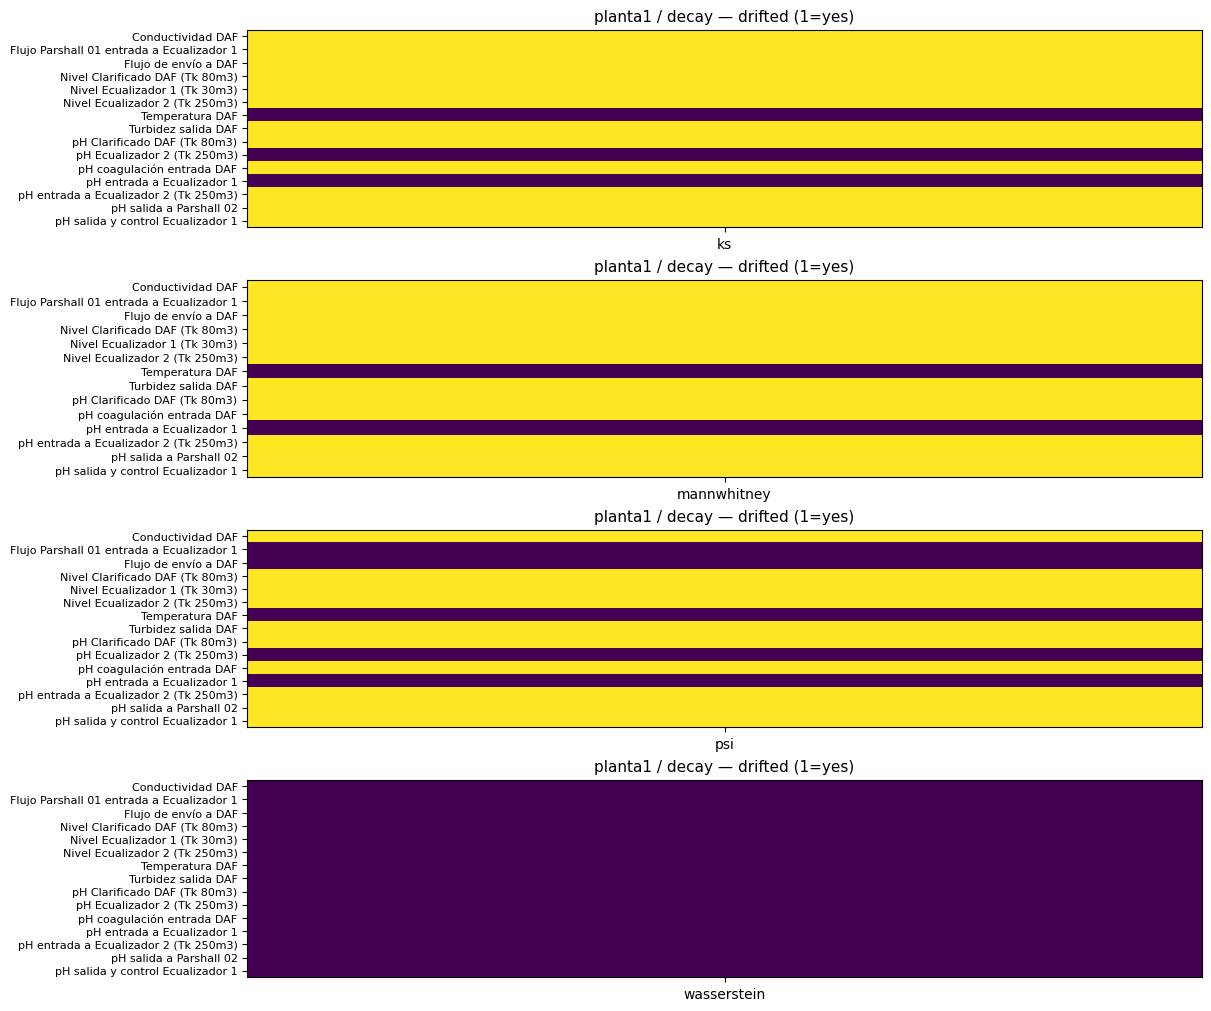

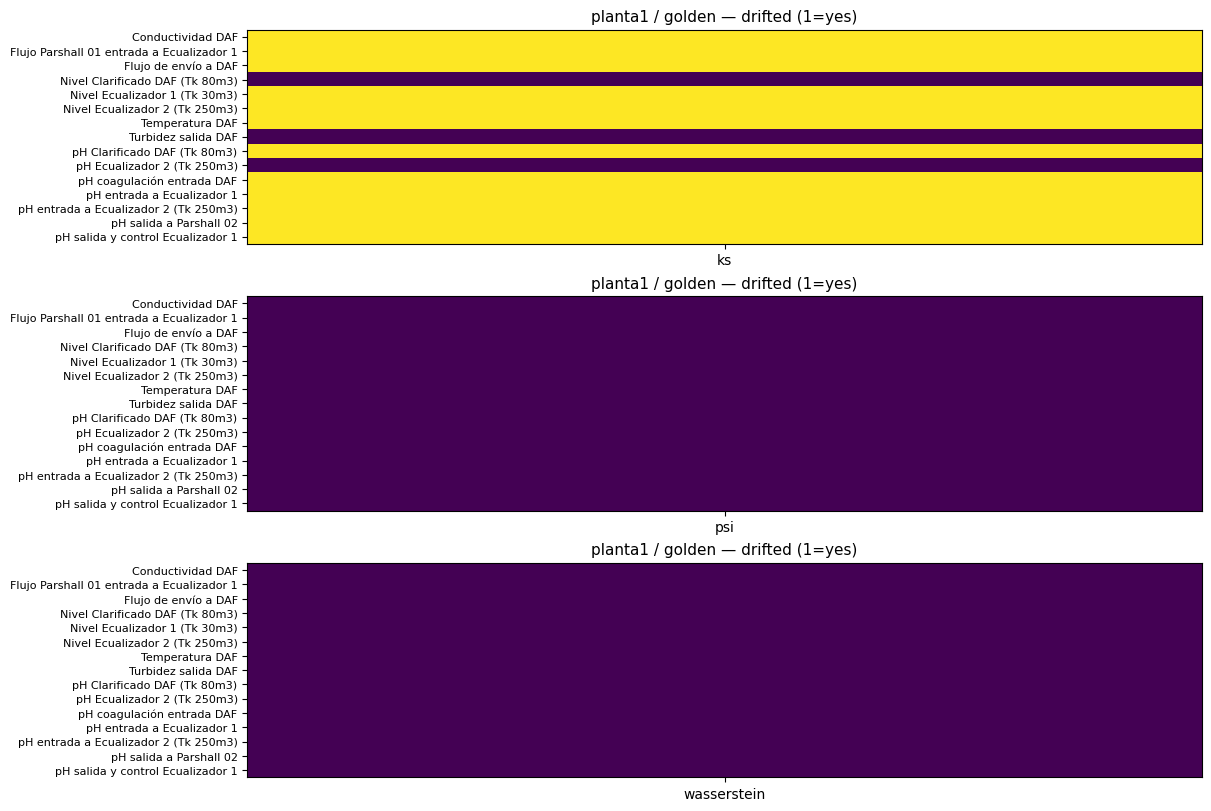

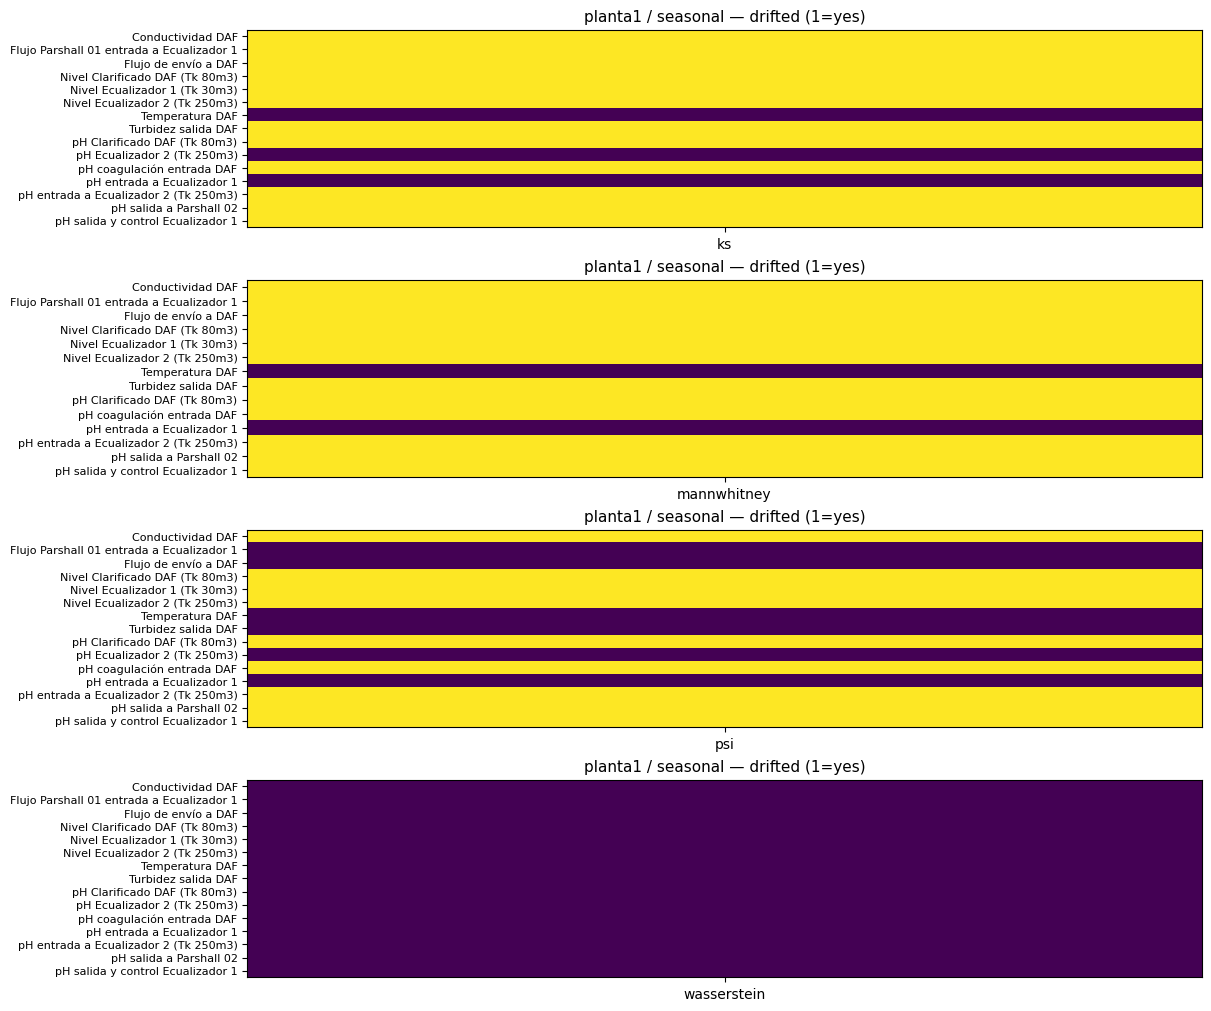

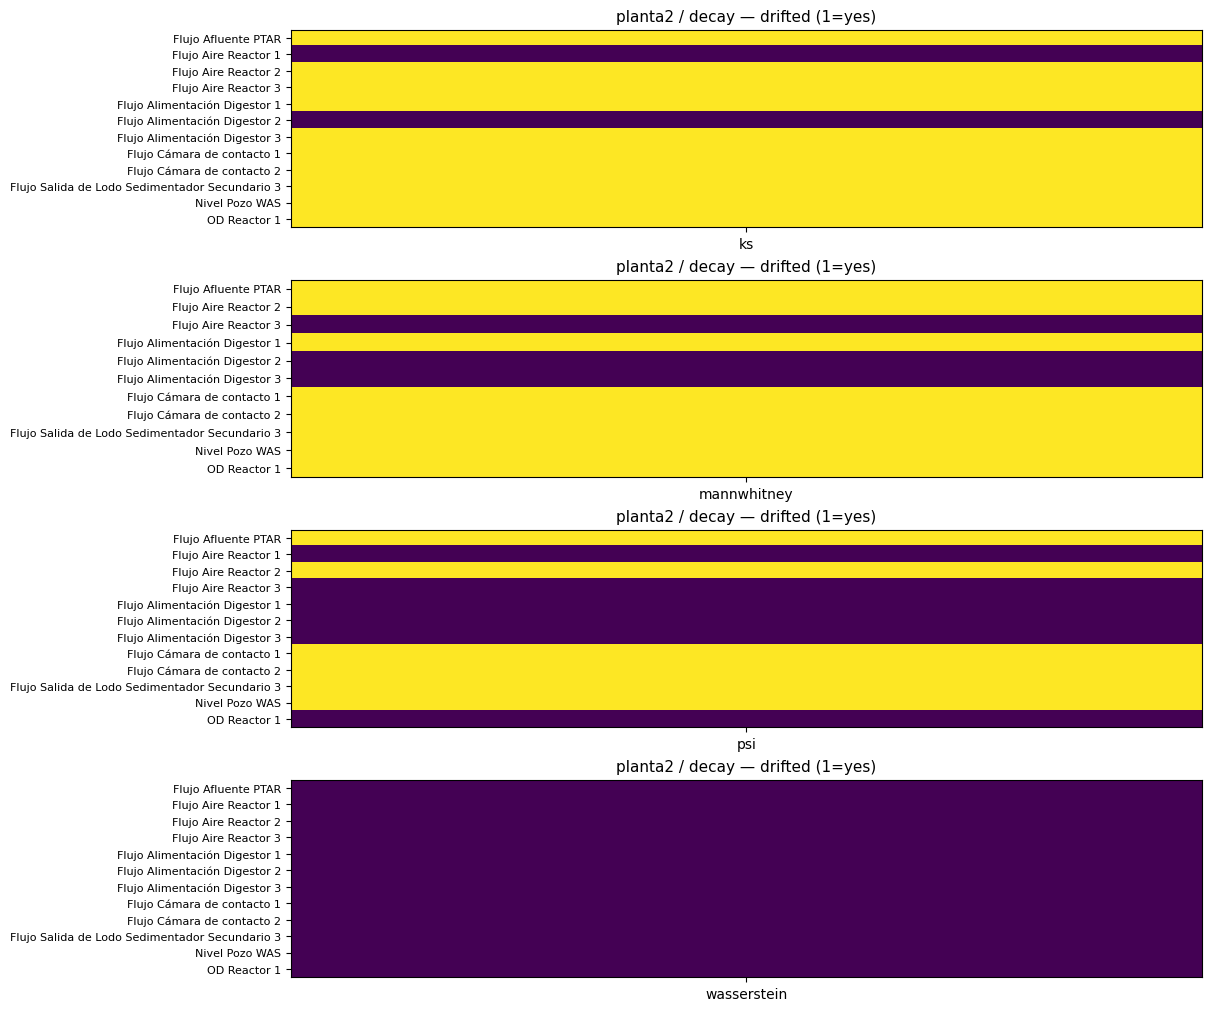

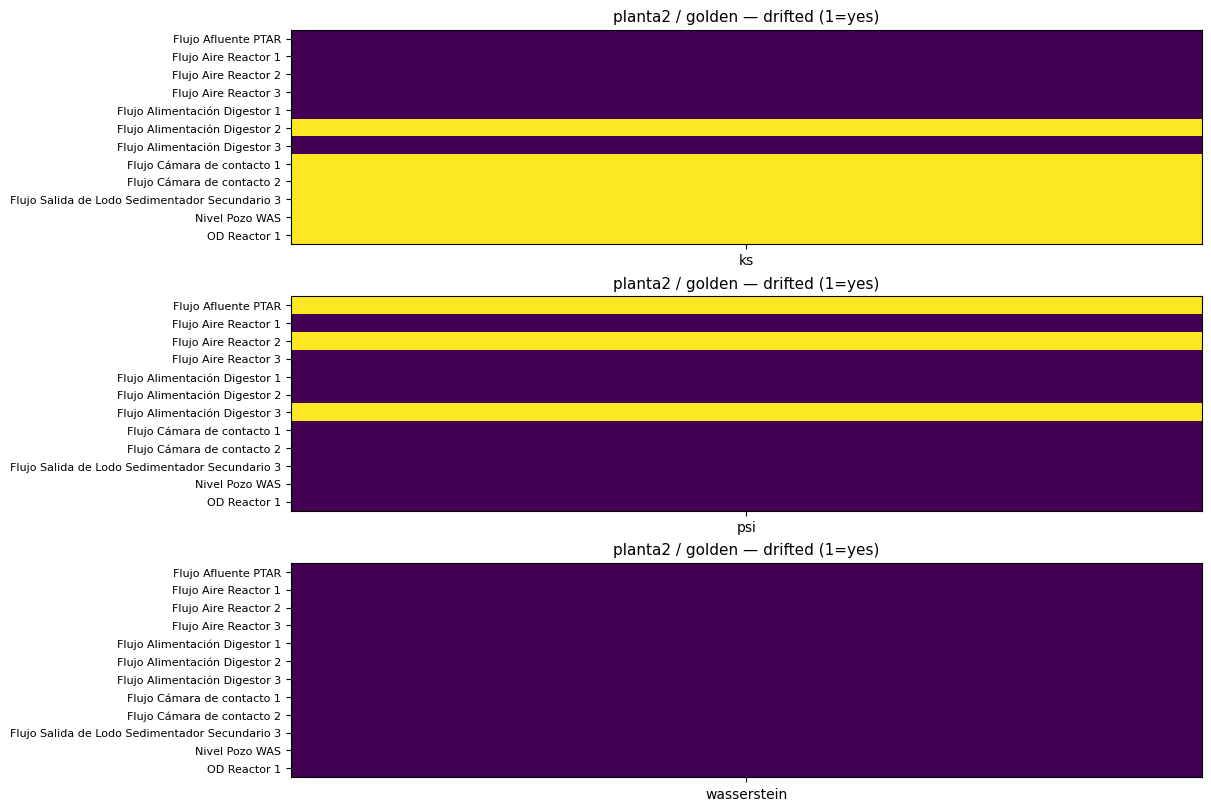

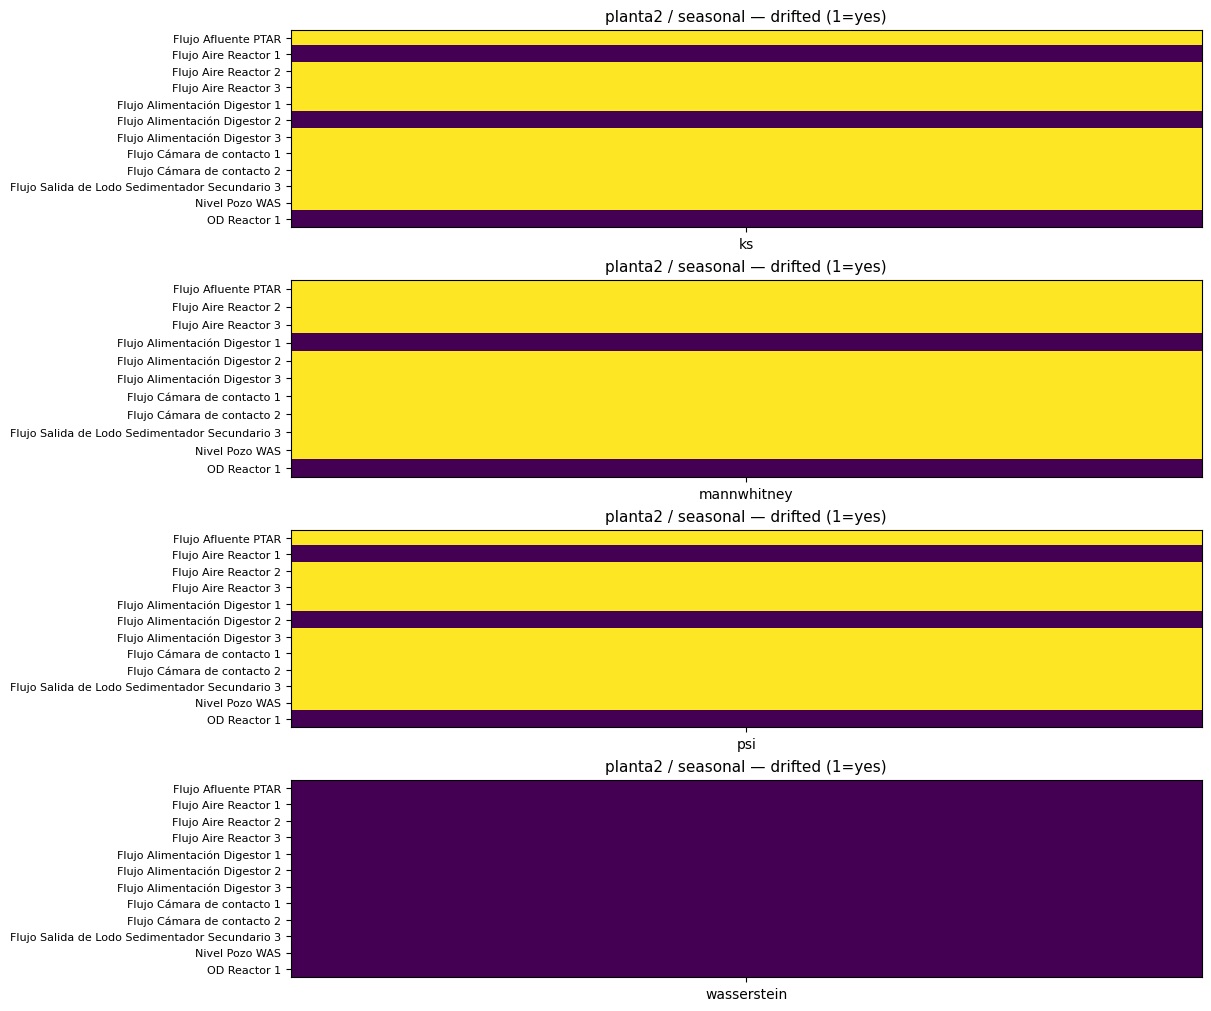

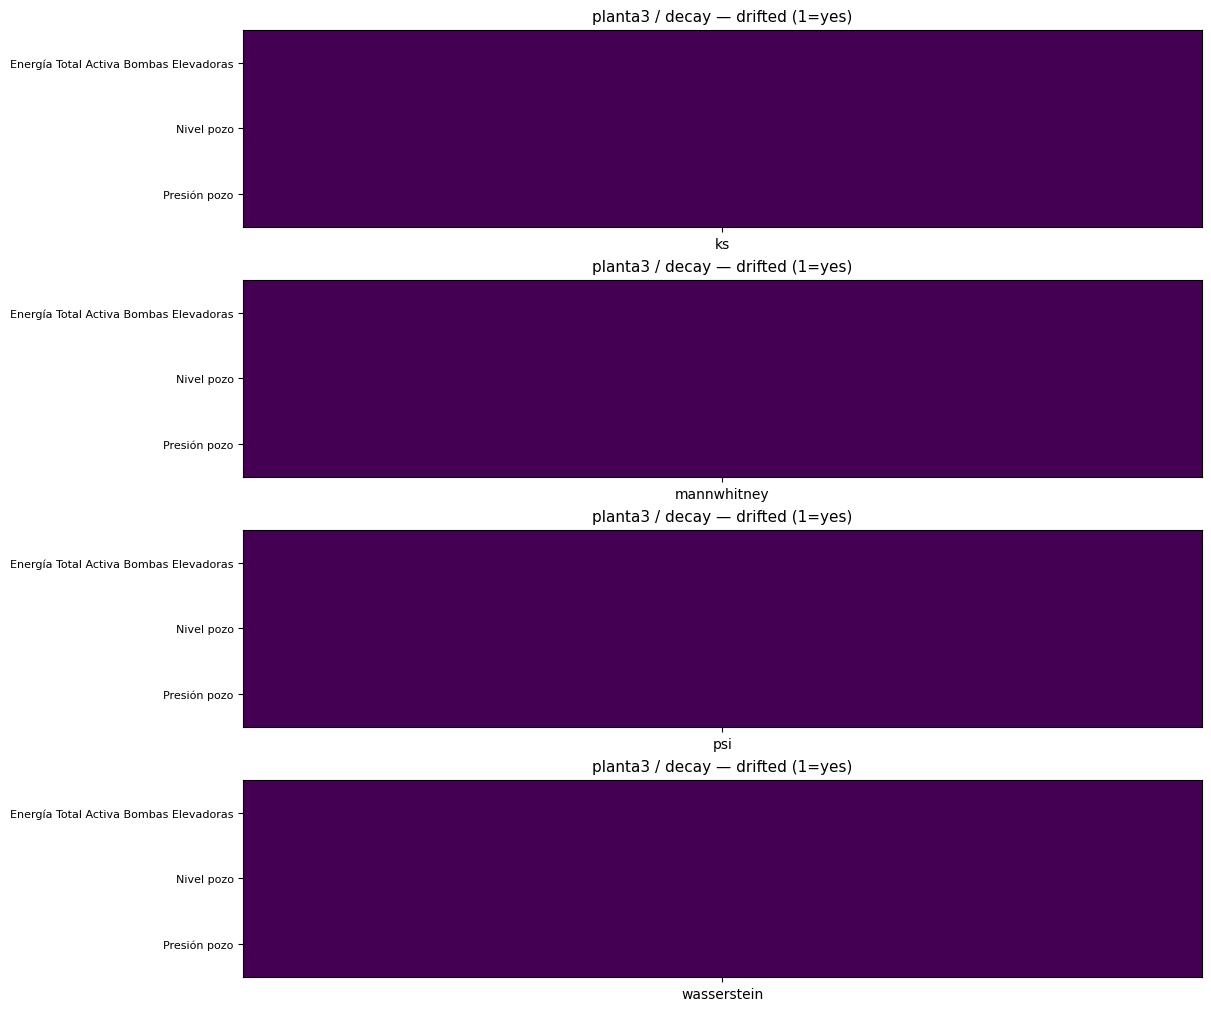

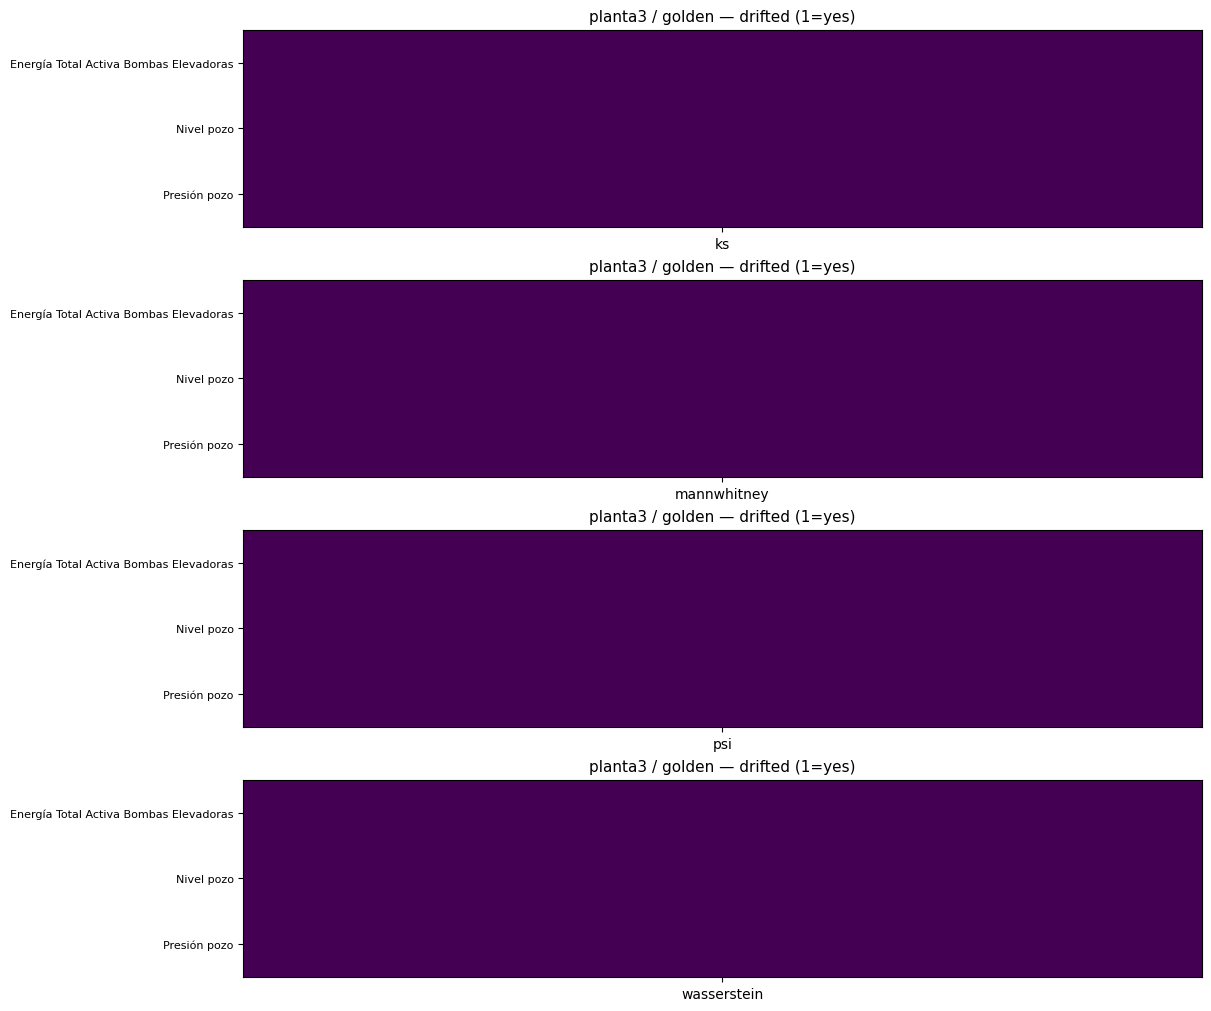

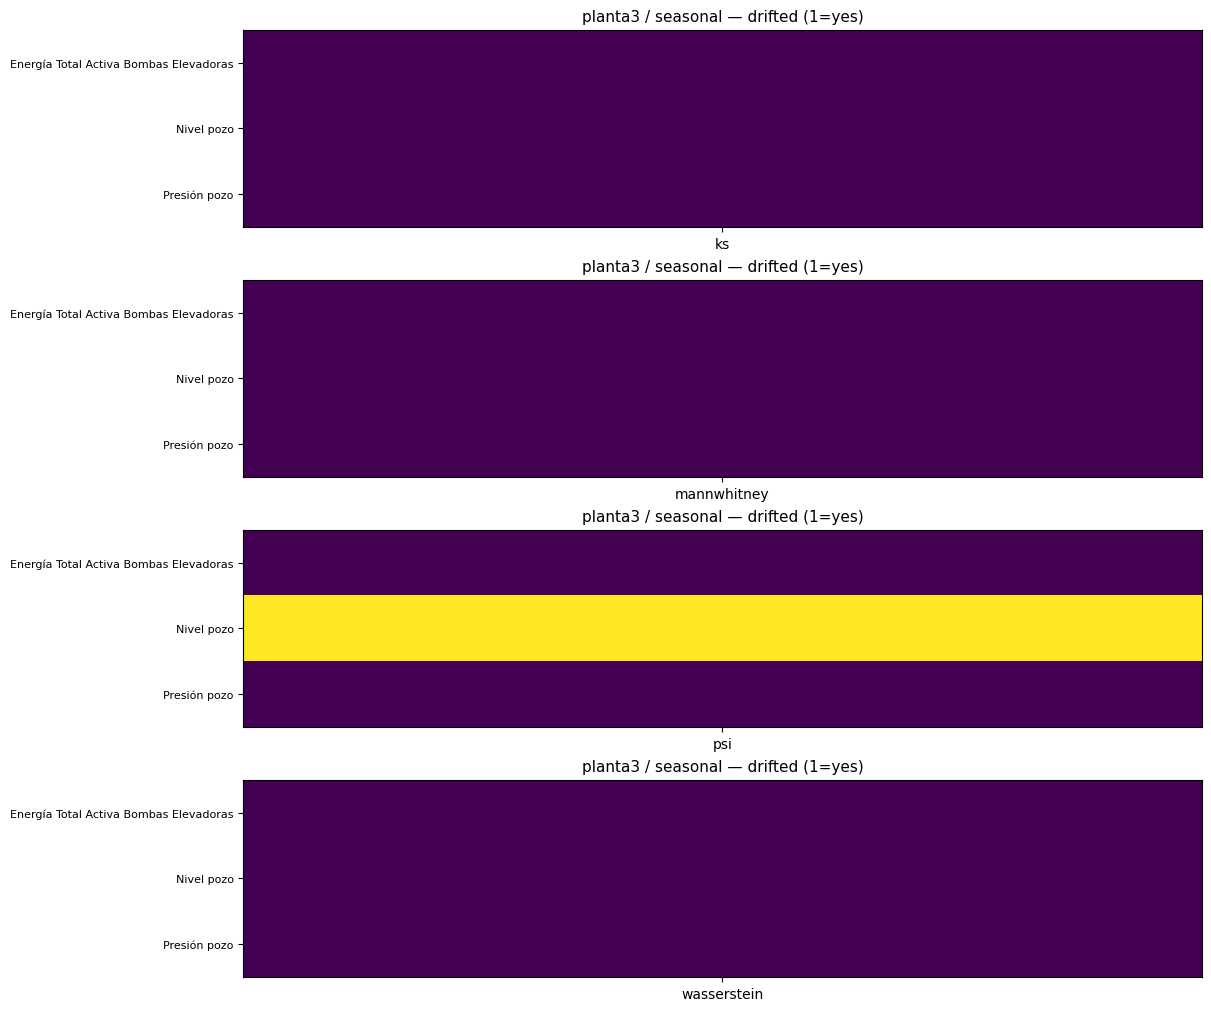

In [8]:
# %% [markdown]
# === 7) VISUALIZACIÓN EN SUBPLOTS (SIN GUARDAR PNGS) ===
# Ejemplo: tiles de "drifted" por (columna x métrica) para una planta/estrategia.

# %%
import matplotlib.pyplot as plt

def plot_tiles_for_plant_strategy(df_cols: pd.DataFrame, plant: str, strategy: str):
    sub = df_cols.query("plant == @plant and strategy == @strategy").copy()
    if sub.empty:
        print(f"[plot] Sin datos para {plant}/{strategy}")
        return
    # Pivoteamos para cada métrica una matriz col x drifted/score
    metrics = sub["metric"].unique().tolist()

    fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(12, 2 + 2*len(metrics)), constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, m in zip(axes, metrics):
        M = (sub[sub["metric"] == m]
             .pivot_table(index="col", columns="metric", values="drifted", aggfunc="max")
             .fillna(0))
        # Como solo una métrica, la columna única es m
        v = M[m].values.reshape(-1,1)
        ax.imshow(v, aspect="auto", interpolation="nearest")
        ax.set_yticks(range(len(M.index)))
        ax.set_yticklabels(M.index, fontsize=8)
        ax.set_xticks([0]); ax.set_xticklabels([m])
        ax.set_title(f"{plant} / {strategy} — drifted (1=yes)", fontsize=11)
    plt.show()

# Ejemplo de uso:
for plant, (df_cols, df_sum) in batch_results.items():
    for strategy in STRATEGIES:
        plot_tiles_for_plant_strategy(df_cols, plant, strategy)
